# Feature & TTA selection: which of the 6 augmentation features, and which TTA views, to use for the final model

**Goal:** answer two questions with real cross-validated evidence before running the final
full-data training and test-set prediction:

1. **Which augmentation feature set** (of the 6 in `roof_seg/augmentation.py`) should the final
   training run use?
2. **Which TTA view set** (of `roof_seg/tta.py`'s geometric-only vs. geometric+color) should the
   final test-set prediction use?

Both are evaluated together, on the **same trained fold models**: augmentation only affects
*training*, TTA only affects *inference*, so for every (augmentation config, fold, seed) model
we already train, we can cheaply evaluate all 3 TTA modes on that fold's held-out validation
images -- unlike the qualitative TTA check on the 6 *real* test images (`scripts/check_tta.py`),
these validation images have ground-truth labels, so this gives actual IoU/Dice numbers for TTA,
not just a pixel-agreement fraction.

**Design, and why:**

- **6 folds x 2 seeds (12 runs per config)**, not 1 seed as in the earlier
  `scripts/compare_augmentation_ensemble.py` comparison -- averaging over two independent fold
  assignments (seed 42 and seed 123) is a stronger check against fold-composition noise, which
  this project has repeatedly found large enough to swallow small effects at N=24 (see SPEC.md's
  0.05-0.10 IoU noise threshold, set in advance of any of these comparisons).
- **Augmentation configs tested:** `no_augmentation`, the established `3_features` baseline
  (flip, rotate90, color_jitter), each of the 3 additional features added individually on top of
  that baseline (isolating each one's own marginal effect -- directly answers "which of the 6
  features should I use"), and the full `6_features` set. 6 configs total.
- **TTA modes tested, on every trained fold's validation images:** `none` (plain forward pass),
  `geometric` (8-way dihedral), `geometric_color` (+ 4 brightness/gamma views). See
  `roof_seg/tta.py`'s module docstring for why perspective/resized_crop aren't TTA-eligible at
  all (no exact per-pixel inverse) -- they're not tested here for that reason, independent of
  whether they help as *training* augmentation.
- **No permanent per-fold checkpoints.** 6 configs x 2 seeds x 6 folds = 72 trained models; at
  ~93MB each (this project's existing checkpoint size) that's ~6.7GB, and this exact machine has
  already hit a disk-space crash once this project (see SPEC.md's incident notes). Instead, each
  fold's result (metrics for all 3 TTA modes, `best_epoch`, `stopped_early`) is appended to a
  JSON log (`outputs/inspection/feature_tta_search.json`) **immediately** after that fold
  finishes, so the search is resumable at the granularity of one (seed, config, fold) unit
  without needing ~7GB of disk for checkpoints that are only useful mid-run.
- **Epoch budget: 25, patience 10** -- same as the existing CV harness convention
  (`scripts/compare_augmentation_ensemble.py`), so `best_epoch` results are comparable to the
  ones already recorded in SPEC.md (~18-21 epochs there, on a single seed).

**Cost warning:** 72 model trainings at 25-epoch budget is substantially more compute than any
single comparison run so far in this project. Expect this to take a while even on a GPU: budget
for it, and rely on the resumable JSON log if it's interrupted (just re-run the training cell --
already-logged (seed, config, fold) combinations are skipped).


In [1]:
from __future__ import annotations

import json
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from roof_seg.augmentation import ALL_FEATURES, DEFAULT_FEATURES  # noqa: E402
from roof_seg.config import INSPECTION_DIR, RANDOM_SEED  # noqa: E402
from roof_seg.cross_validation import make_folds  # noqa: E402
from roof_seg.dataset import RoofTrainDataset  # noqa: E402
from roof_seg.metrics import dice_score, iou_score  # noqa: E402
from roof_seg.seed import set_seed  # noqa: E402
from roof_seg.train import TrainConfig, get_device, train_model  # noqa: E402
from roof_seg.tta import DEFAULT_COLOR_VARIANTS, DIHEDRAL_TRANSFORMS, predict_with_tta  # noqa: E402

print(f"ALL_FEATURES: {ALL_FEATURES}")
print(f"DEFAULT_FEATURES (current baseline): {DEFAULT_FEATURES}")


ALL_FEATURES: ('flip', 'rotate90', 'color_jitter', 'rgb_gamma', 'perspective', 'resized_crop')
DEFAULT_FEATURES (current baseline): ('flip', 'rotate90', 'color_jitter')


## Config

`SEEDS` gives 2 independent fold assignments (12 runs per augmentation config total).
`AUGMENTATION_CONFIGS` isolates each of the 3 extra features' marginal contribution over the
established 3-feature baseline, plus the no-augmentation floor and the full 6-feature set.
`TTA_MODES` are evaluated on every trained fold's validation images (ground truth available,
unlike the real test set) -- `none` reuses `predict_with_tta` with a single identity view, which
is exactly equivalent to a plain forward pass (see `tests/test_tta.py`), so one code path covers
all 3 modes.


In [2]:
SEEDS = [RANDOM_SEED, 123]
N_FOLDS = 6
EPOCHS = 25
PATIENCE = 10
THRESHOLD = 0.5
NOISE_THRESHOLD = 0.05  # SPEC.md's established "don't trust a smaller IoU difference" floor

AUGMENTATION_CONFIGS: dict[str, tuple[str, ...] | None] = {
    "no_augmentation": None,
    "3_features": DEFAULT_FEATURES,
    "3_features+rgb_gamma": DEFAULT_FEATURES + ("rgb_gamma",),
    "3_features+perspective": DEFAULT_FEATURES + ("perspective",),
    "3_features+resized_crop": DEFAULT_FEATURES + ("resized_crop",),
    "6_features": ALL_FEATURES,
}

TTA_MODES: dict[str, dict] = {
    "none": {"transforms": ((False, 0),), "color_variants": None},
    "geometric": {"transforms": DIHEDRAL_TRANSFORMS, "color_variants": None},
    "geometric_color": {"transforms": DIHEDRAL_TRANSFORMS, "color_variants": DEFAULT_COLOR_VARIANTS},
}

LOG_PATH = INSPECTION_DIR / "feature_tta_search.json"

device = get_device()
print(f"Device: {device}")
print(f"Augmentation configs: {list(AUGMENTATION_CONFIGS)}")
print(f"TTA modes: {list(TTA_MODES)}")
print(f"Total (seed, config, fold) training units: {len(SEEDS) * len(AUGMENTATION_CONFIGS) * N_FOLDS}")


Device: cuda
Augmentation configs: ['no_augmentation', '3_features', '3_features+rgb_gamma', '3_features+perspective', '3_features+resized_crop', '6_features']
TTA modes: ['none', 'geometric', 'geometric_color']
Total (seed, config, fold) training units: 72


## Helpers: config_for, evaluate_with_tta, JSON log

`evaluate_with_tta` mirrors `roof_seg.train.evaluate()` (same per-sample IoU/Dice averaging,
same "no augmentation on validation data" loading via `RoofTrainDataset(ids=..., transform=None)`)
but routes the forward pass through `predict_with_tta()` instead of a single plain call, so it
can score any of the 3 `TTA_MODES` against ground truth.


In [3]:
def config_for(features: tuple[str, ...] | None, seed: int) -> TrainConfig:
    if features is None:
        return TrainConfig(epochs=EPOCHS, early_stopping_patience=PATIENCE, seed=seed, augment=False)
    return TrainConfig(
        epochs=EPOCHS, early_stopping_patience=PATIENCE, seed=seed,
        augment=True, augment_features=features,
    )


@torch.no_grad()
def evaluate_with_tta(model, ids, transforms, color_variants, threshold=THRESHOLD, device=None):
    device = device or get_device()
    model.eval()
    dataset = RoofTrainDataset(ids=ids)  # no transform: never augment evaluation data

    ious, dices = [], []
    for i in range(len(dataset)):
        sample = dataset[i]
        probs = predict_with_tta(
            model, sample["image"], device=device, transforms=transforms, color_variants=color_variants
        )[0].numpy()
        pred = probs > threshold
        target = sample["mask"][0].numpy()
        ious.append(iou_score(pred, target))
        dices.append(dice_score(pred, target))
    return {"iou": float(np.mean(ious)), "dice": float(np.mean(dices))}


def load_log(path: Path) -> dict:
    if path.exists():
        return json.loads(path.read_text(encoding="utf-8"))
    return {"runs": []}


def save_log(path: Path, log: dict) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(log, indent=2), encoding="utf-8")


def already_done(log: dict, seed: int, aug_name: str, fold: int) -> bool:
    return any(
        r["seed"] == seed and r["aug_config"] == aug_name and r["fold"] == fold
        for r in log["runs"]
    )


## Run the search

Resumable: re-running this cell skips any (seed, aug_config, fold) already present in
`outputs/inspection/feature_tta_search.json`.


In [4]:
log = load_log(LOG_PATH)
print(f"Resuming with {len(log['runs'])} (seed, config, fold) results already logged.")

total_units = len(SEEDS) * len(AUGMENTATION_CONFIGS) * N_FOLDS
done_units = 0

for seed in SEEDS:
    set_seed(seed)
    folds = make_folds(n_folds=N_FOLDS, seed=seed)

    for aug_name, features in AUGMENTATION_CONFIGS.items():
        for fold_idx, (train_ids, val_ids) in enumerate(folds):
            done_units += 1
            if already_done(log, seed, aug_name, fold_idx):
                print(f"[{done_units}/{total_units}] [cached] seed={seed} {aug_name} fold={fold_idx}")
                continue

            t0 = time.time()
            cfg = config_for(features, seed)
            result = train_model(
                train_ids=train_ids, val_ids=val_ids, config=cfg, progress=False, device=device
            )

            tta_metrics = {
                tta_name: evaluate_with_tta(result.model, val_ids, device=device, **tta_kwargs)
                for tta_name, tta_kwargs in TTA_MODES.items()
            }
            elapsed = time.time() - t0

            log["runs"].append({
                "seed": seed,
                "aug_config": aug_name,
                "fold": fold_idx,
                "best_epoch": result.best_epoch,
                "stopped_early": result.stopped_early,
                "epochs_run": len(result.train_losses),
                "tta_metrics": tta_metrics,
                "elapsed_seconds": elapsed,
            })
            save_log(LOG_PATH, log)

            best_iou = tta_metrics["geometric"]["iou"]
            print(
                f"[{done_units}/{total_units}] seed={seed} {aug_name} fold={fold_idx}: "
                f"best_epoch={result.best_epoch} geometric_iou={best_iou:.3f} ({elapsed:.0f}s)"
            )

print(f"\nDone. {len(log['runs'])} total (seed, config, fold) results logged to {LOG_PATH}")


Resuming with 0 (seed, config, fold) results already logged.
[1/72] seed=42 no_augmentation fold=0: best_epoch=23 geometric_iou=0.676 (75s)
[2/72] seed=42 no_augmentation fold=1: best_epoch=9 geometric_iou=0.602 (57s)
[3/72] seed=42 no_augmentation fold=2: best_epoch=21 geometric_iou=0.647 (75s)
[4/72] seed=42 no_augmentation fold=3: best_epoch=24 geometric_iou=0.694 (75s)
[5/72] seed=42 no_augmentation fold=4: best_epoch=12 geometric_iou=0.743 (66s)
[6/72] seed=42 no_augmentation fold=5: best_epoch=11 geometric_iou=0.638 (64s)
[7/72] seed=42 3_features fold=0: best_epoch=25 geometric_iou=0.714 (76s)
[8/72] seed=42 3_features fold=1: best_epoch=10 geometric_iou=0.678 (61s)
[9/72] seed=42 3_features fold=2: best_epoch=25 geometric_iou=0.774 (77s)
[10/72] seed=42 3_features fold=3: best_epoch=20 geometric_iou=0.753 (77s)
[11/72] seed=42 3_features fold=4: best_epoch=25 geometric_iou=0.751 (77s)
[12/72] seed=42 3_features fold=5: best_epoch=23 geometric_iou=0.703 (77s)
[13/72] seed=42 3_f

## Aggregate: augmentation x TTA grid

Mean/std IoU and Dice for every (augmentation config, TTA mode) pair, averaged over all
`len(SEEDS) * N_FOLDS` = 12 (seed, fold) results per config -- the *same* underlying fold models
across the 3 TTA-mode columns, so this grid isolates the TTA effect cleanly (paired by
construction) on top of the augmentation effect.


In [5]:
def grid_values(log: dict, metric: str = "iou") -> dict[str, dict[str, list[float]]]:
    grid: dict[str, dict[str, list[float]]] = {
        aug: {tta: [] for tta in TTA_MODES} for aug in AUGMENTATION_CONFIGS
    }
    for run in log["runs"]:
        for tta_name, metrics in run["tta_metrics"].items():
            grid[run["aug_config"]][tta_name].append(metrics[metric])
    return grid


iou_grid = grid_values(log, "iou")
dice_grid = grid_values(log, "dice")

header = f"{'augmentation':<26}" + "".join(f"{tta:>20}" for tta in TTA_MODES)
print(header)
print("-" * len(header))
for aug_name in AUGMENTATION_CONFIGS:
    row = f"{aug_name:<26}"
    for tta_name in TTA_MODES:
        values = iou_grid[aug_name][tta_name]
        if values:
            row += f"{np.mean(values):>14.3f}+/-{np.std(values):.3f}"
        else:
            row += f"{'(no data)':>20}"
    print(row)


augmentation                              none           geometric     geometric_color
--------------------------------------------------------------------------------------
no_augmentation                    0.686+/-0.036         0.649+/-0.053         0.682+/-0.041
3_features                         0.726+/-0.036         0.743+/-0.036         0.745+/-0.033
3_features+rgb_gamma               0.730+/-0.028         0.740+/-0.035         0.741+/-0.032
3_features+perspective             0.726+/-0.034         0.732+/-0.031         0.736+/-0.032
3_features+resized_crop            0.719+/-0.042         0.723+/-0.040         0.727+/-0.040
6_features                         0.719+/-0.032         0.727+/-0.033         0.729+/-0.033


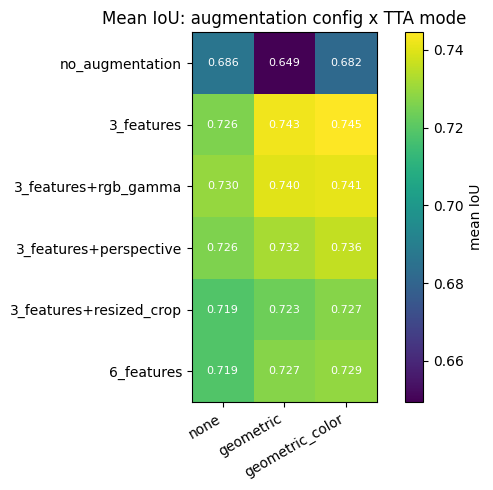

In [6]:
fig, ax = plt.subplots(figsize=(6, 5))
matrix = np.array([
    [np.mean(iou_grid[aug][tta]) if iou_grid[aug][tta] else np.nan for tta in TTA_MODES]
    for aug in AUGMENTATION_CONFIGS
])
im = ax.imshow(matrix, cmap="viridis", vmin=np.nanmin(matrix), vmax=np.nanmax(matrix))
ax.set_xticks(range(len(TTA_MODES)))
ax.set_xticklabels(list(TTA_MODES), rotation=30, ha="right")
ax.set_yticks(range(len(AUGMENTATION_CONFIGS)))
ax.set_yticklabels(list(AUGMENTATION_CONFIGS))
for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        if not np.isnan(matrix[i, j]):
            ax.text(j, i, f"{matrix[i, j]:.3f}", ha="center", va="center", color="white", fontsize=8)
ax.set_title("Mean IoU: augmentation config x TTA mode")
fig.colorbar(im, ax=ax, label="mean IoU")
fig.tight_layout()
plt.show()


## Pick the winning (augmentation, TTA) combination

Picks the highest mean-IoU cell, then checks the paired difference against the current baseline
(`3_features` + `geometric` TTA) using this project's established 0.05-0.10 noise threshold
(SPEC.md) -- if the improvement doesn't clear it, the recommendation defaults back to the
baseline rather than chasing noise.


In [7]:
BASELINE_AUG = "3_features"
BASELINE_TTA = "geometric"

best_aug, best_tta, best_mean = None, None, -1.0
for aug_name in AUGMENTATION_CONFIGS:
    for tta_name in TTA_MODES:
        values = iou_grid[aug_name][tta_name]
        if values and np.mean(values) > best_mean:
            best_aug, best_tta, best_mean = aug_name, tta_name, np.mean(values)

baseline_values = np.array(iou_grid[BASELINE_AUG][BASELINE_TTA])
best_values = np.array(iou_grid[best_aug][best_tta])
diff = best_values.mean() - baseline_values.mean() if len(baseline_values) == len(best_values) else None

print(f"Best cell by mean IoU: aug={best_aug!r}, tta={best_tta!r}, mean IoU={best_mean:.3f}")
print(f"Baseline: aug={BASELINE_AUG!r}, tta={BASELINE_TTA!r}, "
      f"mean IoU={baseline_values.mean():.3f}+/-{baseline_values.std():.3f}")

if best_aug == BASELINE_AUG and best_tta == BASELINE_TTA:
    print("\nBest cell IS the baseline -- no change recommended.")
    recommended_aug, recommended_tta = BASELINE_AUG, BASELINE_TTA
elif diff is not None and diff > NOISE_THRESHOLD:
    print(f"\nImprovement over baseline: +{diff:.3f} IoU, clears the {NOISE_THRESHOLD} noise "
          f"threshold -- recommending the new combination.")
    recommended_aug, recommended_tta = best_aug, best_tta
else:
    diff_str = f"{diff:+.3f}" if diff is not None else "N/A (unpaired run counts)"
    print(f"\nBest cell's improvement over baseline ({diff_str} IoU) does NOT clear the "
          f"{NOISE_THRESHOLD} noise threshold -- keeping the baseline rather than chasing noise, "
          f"per SPEC.md's established convention.")
    recommended_aug, recommended_tta = BASELINE_AUG, BASELINE_TTA

print(f"\n=> RECOMMENDED final augmentation config: {recommended_aug!r} "
      f"({AUGMENTATION_CONFIGS[recommended_aug]})")
print(f"=> RECOMMENDED final TTA mode: {recommended_tta!r} ({TTA_MODES[recommended_tta]})")


Best cell by mean IoU: aug='3_features', tta='geometric_color', mean IoU=0.745
Baseline: aug='3_features', tta='geometric', mean IoU=0.743+/-0.036

Best cell's improvement over baseline (+0.002 IoU) does NOT clear the 0.05 noise threshold -- keeping the baseline rather than chasing noise, per SPEC.md's established convention.

=> RECOMMENDED final augmentation config: '3_features' (('flip', 'rotate90', 'color_jitter'))
=> RECOMMENDED final TTA mode: 'geometric' ({'transforms': ((False, 0), (False, 1), (False, 2), (False, 3), (True, 0), (True, 1), (True, 2), (True, 3)), 'color_variants': None})


## Best-epoch recommendation for the final (no-validation) training run

The final deliverable trains on all 24 images with **no** held-out split (SPEC §3.7), so it has
no early-stopping signal of its own -- it always runs a fixed epoch budget. The CV runs above,
which *do* have a validation split, give a best-epoch distribution to base that fixed budget on.
Uses only the runs from the recommended augmentation config (epoch dynamics can differ somewhat
by augmentation strength).


In [8]:
best_epochs = [
    run["best_epoch"] for run in log["runs"]
    if run["aug_config"] == recommended_aug and run["best_epoch"] is not None
]

print(f"Best-epoch distribution for {recommended_aug!r} ({len(best_epochs)} runs, "
      f"{len(SEEDS)} seeds x {N_FOLDS} folds):")
print(f"  values: {sorted(best_epochs)}")
print(f"  mean:   {np.mean(best_epochs):.1f}")
print(f"  median: {np.median(best_epochs):.1f}")
print(f"  min/max: {min(best_epochs)}/{max(best_epochs)}")

stopped_early_count = sum(
    1 for run in log["runs"] if run["aug_config"] == recommended_aug and run["stopped_early"]
)
capped_at_budget = sum(1 for e in best_epochs if e == EPOCHS)
print(f"  stopped early: {stopped_early_count}/{len(best_epochs)}")
print(f"  hit the {EPOCHS}-epoch budget cap (best epoch may be understated): {capped_at_budget}/{len(best_epochs)}")

# Recommend a small margin over the mean best epoch, since the final run trains on more data
# (24 images, not ~20 per fold) and has no early stopping to fall back on if it needs a bit longer.
recommended_epochs = int(np.ceil(np.mean(best_epochs) * 1.15))
print(f"\n=> RECOMMENDED final epoch budget: {recommended_epochs} "
      f"(mean best epoch {np.mean(best_epochs):.1f} + 15% margin, no early stopping available)")

if capped_at_budget:
    print(
        f"\nWARNING: {capped_at_budget} fold(s) hit the {EPOCHS}-epoch search budget as their "
        "best epoch -- the true best epoch for those folds may be higher than recorded here. "
        "Consider re-running the search with a larger EPOCHS budget if this fraction is large."
    )


Best-epoch distribution for '3_features' (12 runs, 2 seeds x 6 folds):
  values: [10, 20, 20, 21, 21, 23, 23, 23, 24, 25, 25, 25]
  mean:   21.7
  median: 23.0
  min/max: 10/25
  stopped early: 1/12
  hit the 25-epoch budget cap (best epoch may be understated): 3/12

=> RECOMMENDED final epoch budget: 25 (mean best epoch 21.7 + 15% margin, no early stopping available)



## How to run the final training and test-set prediction

Uses whatever `recommended_aug` / `recommended_tta` / `recommended_epochs` were computed above
(printed again here so this cell is copy-pastable even if you only run this last section).


In [9]:
features_arg = ",".join(AUGMENTATION_CONFIGS[recommended_aug]) if AUGMENTATION_CONFIGS[recommended_aug] else None

print("Final training command:")
if features_arg:
    print(f"  python scripts/train.py --epochs {recommended_epochs} --augment-features {features_arg}")
else:
    print(f"  python scripts/train.py --epochs {recommended_epochs} --no-augment")

print()
print("Final test-set prediction: run inference with roof_seg.tta.predict_with_tta() using:")
print(f"  transforms      = {TTA_MODES[recommended_tta]['transforms']!r}"
      if TTA_MODES[recommended_tta]["transforms"] != DIHEDRAL_TRANSFORMS
      else "  transforms      = roof_seg.tta.DIHEDRAL_TRANSFORMS  # (the default)")
print(f"  color_variants  = {'roof_seg.tta.DEFAULT_COLOR_VARIANTS' if TTA_MODES[recommended_tta]['color_variants'] else 'None'}")
print()
print("scripts/check_tta.py already demonstrates exactly this call pattern (plain / geometric / "
      "geometric+color) on the real 6 test images -- point it at the checkpoint the command "
      "above produces (outputs/checkpoints/best_model.pt by default) to render the final "
      "prediction grid: `python scripts/check_tta.py`.")


Final training command:
  python scripts/train.py --epochs 25 --augment-features flip,rotate90,color_jitter

Final test-set prediction: run inference with roof_seg.tta.predict_with_tta() using:
  transforms      = roof_seg.tta.DIHEDRAL_TRANSFORMS  # (the default)
  color_variants  = None

scripts/check_tta.py already demonstrates exactly this call pattern (plain / geometric / geometric+color) on the real 6 test images -- point it at the checkpoint the command above produces (outputs/checkpoints/best_model.pt by default) to render the final prediction grid: `python scripts/check_tta.py`.
